In [81]:
## import dependencies
import os
import re
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Add the path to the DiscEvolution directory
sys.path.append('/Users/ben/Downloads/Planet Formation/Code/DiscEvolution Core Accretion')

## import DiscEvolution modules
from DiscEvolution.constants import *
from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import IrradiatedEOS, LocallyIsothermalEOS, SimpleDiscEOS
from DiscEvolution.disc import *
from DiscEvolution.viscous_evolution import ViscousEvolution, ViscousEvolutionFV, LBP_Solution, HybridWindModel, TaboneSolution
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.dust import *
from DiscEvolution.dust import PlanetesimalFormation
from DiscEvolution.planet_formation import *
from DiscEvolution.diffusion import TracerDiffusion
from DiscEvolution.opacity import Tazzari2016
from DiscEvolution.chemistry import *

In [82]:
## Method to read data from an HDF5 dataset or group

def read_hdf5_array(obj):
    """
    Read data from either an HDF5 dataset or an HDF5 group.
    """

    ## Normal case (the data are stored as one HDF5 dataset)
    if isinstance(obj, h5py.Dataset):
        return np.array(obj)

    ## Ragged case (the data are stored as a group)
    elif isinstance(obj, h5py.Group):
        values = []

        for key in sorted(obj.keys(), key = int):
            values.append(np.array(obj[key]))

        return values

    ## Raise an error if an unexpected HDF5 object is encountered
    else:
        raise TypeError(f"Unexpected HDF5 object type: {type(obj)}")

## Method to load data from an HDF5 file

def load_data(filename, planets = True):
    """
    Load disc evolution output file (HDF5 only).

    Parameters:
        filename: Path to the HDF5 file.
        planets: Whether to load planet data.

    Returns:
        data: Dictionary containing the simulation output.
    """

    data = {}

    ## Extract the psi value from the filename
    match = re.search(r"psi([0-9.eE+-]+)", os.path.basename(filename))

    if match:
        psi = float(match.group(1))

    else:
        psi = None

    ## Open the HDF5 file in read-only mode
    with h5py.File(filename, "r") as f:

        ## ---------------- General simulation data ----------------

        general_keys = [
            "t",
            "disk_Mdot_star",
            "disk_Mass",
            "Tc",
            "Sigc"]

        for key in general_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = np.array(f[key])


        ## ---------------- Alpha viscosity ----------------

        if "alpha_SS" in f:
            data["alpha_SS"] = float(f["alpha_SS"][()])

        elif "alpha_SS" in f.attrs:
            data["alpha_SS"] = float(f.attrs["alpha_SS"])

        else:
            data["alpha_SS"] = None

        if psi is not None:
            data["psi"] = psi

        ## ---------------- Disk profiles ----------------

        disk_keys = [
            "R",
            "Sigma_G",
            "Sigma_dust",
            "Sigma_pebbles",
            "Sigma_planetesimals",
            "Vdrift_grains",
            "Vdrift_pebbles",
            "St_grains",
            "St_pebbles",
            "St_planetesimals",
            "e_planetesimals",
            "i_planetesimals",
            "de2_dt",
            "di2_dt",
            "de2_dt_drag",
            "di2_dt_drag",
            "de2_dt_VS_embryo",
            "di2_dt_VS_embryo",
            "de2_dt_VS_pltsml",
            "di2_dt_VS_pltsml",
            "de2_dt_DF",
            "di2_dt_DF",
            "T"]

        for key in disk_keys:
            if key in f:
                data[key] = read_hdf5_array(f[key])

        ## ---------------- Planet data ----------------

        if planets:
            planet_keys = [
                "Mcs",
                "Mes",
                "Rp",
                "Mdot_planetesimal",
                "Mdot_pebble",
                "Mdot_migration",
                "Mdot_gas",
                "M_iso_planetesimal",
                "M_iso_pebble",
                "X_cores",
                "X_envs"]

            for key in planet_keys:
                if key in f:
                    data[key] = read_hdf5_array(f[key])

    return data

In [83]:
data = load_data("/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260731_1122_psi10_Mdot3.0e-09_M0.1_Rd50.h5", planets = True)

## Disc profiles
R = data["R"]

## Surface density profiles
Sigma_G = data["Sigma_G"]
Sigma_grains = data["Sigma_dust"]
Sigma_pebble = data["Sigma_pebbles"]
Sigma_planetesimal = data["Sigma_planetesimals"]

## Eccentricity and inclination profiles
e_planetesimal = data["e_planetesimals"]
i_planetesimal = data["i_planetesimals"]

## Eccentricity and inclination derivatives
de2_dt = data["de2_dt"]
di2_dt = data["di2_dt"]
de2_dt_drag = data["de2_dt_drag"]
di2_dt_drag = data["di2_dt_drag"]
de2_dt_VS_embryo = data["de2_dt_VS_embryo"]
di2_dt_VS_embryo = data["di2_dt_VS_embryo"]
de2_dt_VS_pltsml = data["de2_dt_VS_pltsml"]
di2_dt_VS_pltsml = data["di2_dt_VS_pltsml"]
de2_dt_DF = data["de2_dt_DF"]
di2_dt_DF = data["di2_dt_DF"]

## Accretion rates
Mdot_planetesimal = data["Mdot_planetesimal"]
Mdot_pebble = data["Mdot_pebble"]
Mdot_migration = data["Mdot_migration"]
Mdot_gas = data["Mdot_gas"]

## Planet properties
Rp = data["Rp"]
Mcs = data["Mcs"]
Mes = data["Mes"]
M_iso_planetesimal = data["M_iso_planetesimal"]
M_iso_pebble = data["M_iso_pebble"]

## Time data
t = data["t"]
t_interval = [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1.0]

In [84]:
## Matplotlib colors

n_times = len(t_interval)

color_blues = plt.cm.Blues(np.linspace(1, 0.4, n_times))
color_greys = plt.cm.Greys(np.linspace(1, 0.4, n_times))
color_greens = plt.cm.Greens(np.linspace(1, 0.4, n_times))
color_reds = plt.cm.Reds(np.linspace(1, 0.4, n_times))

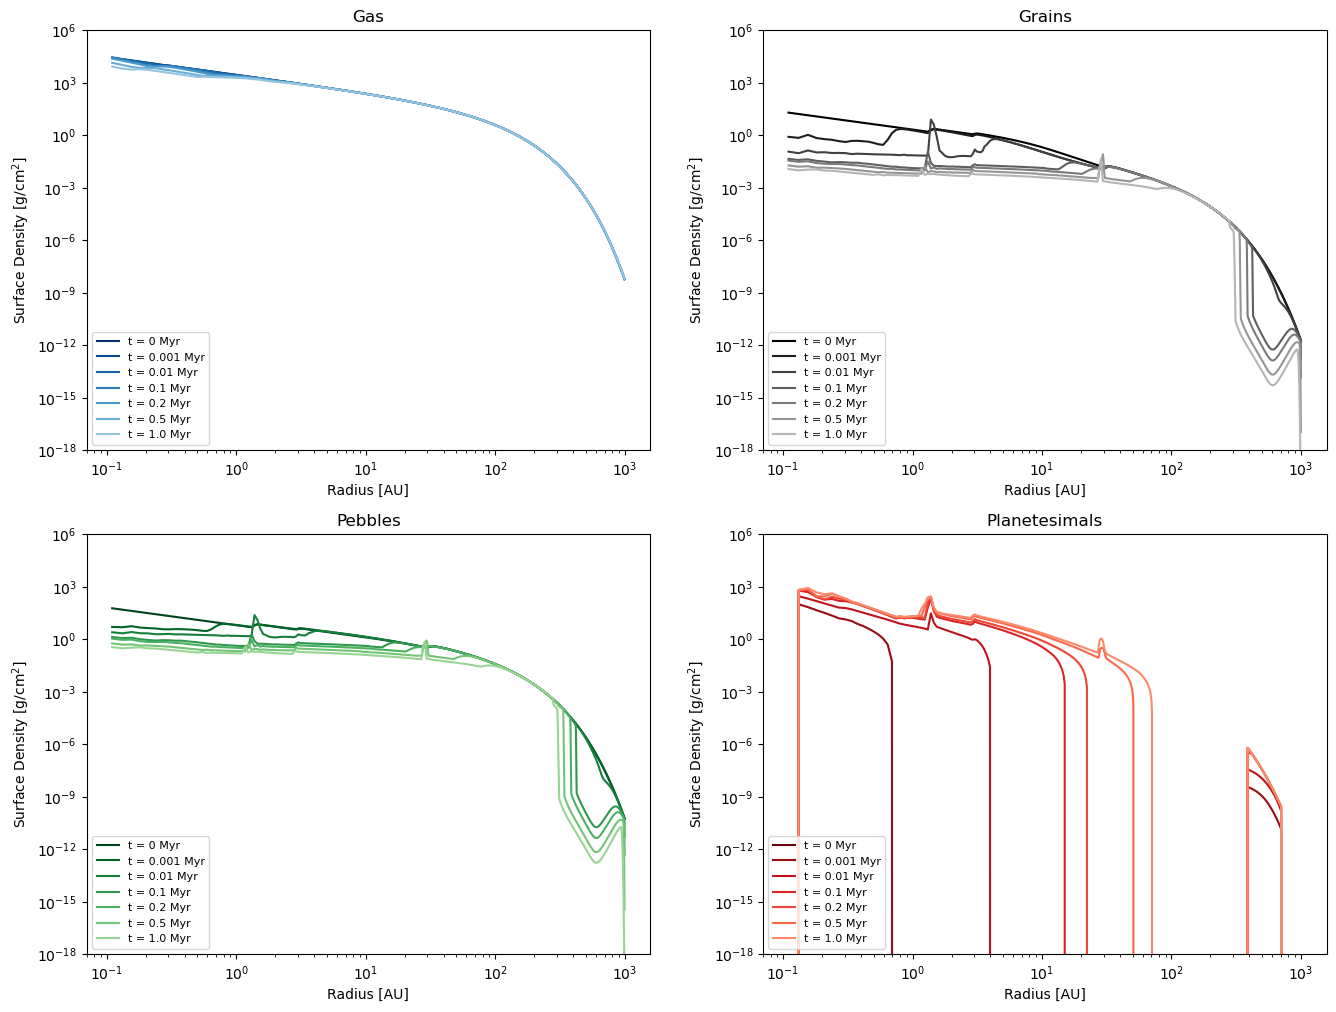

In [85]:
## Plot surface density profiles

n_times = len(t_interval)

fig, ax = plt.subplots(2, 2, figsize = (8 * 2, 6 * 2))

for i in range(n_times):
    ax[0, 0].plot(R[i], Sigma_G[i], color = color_blues[i], label = f't = {t_interval[i]} Myr')
    ax[0, 1].plot(R[i], Sigma_grains[i], color = color_greys[i], label = f't = {t_interval[i]} Myr')
    ax[1, 0].plot(R[i], Sigma_pebble[i], color = color_greens[i], label = f't = {t_interval[i]} Myr')
    ax[1, 1].plot(R[i], Sigma_planetesimal[i], color = color_reds[i], label = f't = {t_interval[i]} Myr')

for i in range(2):
    for j in range(2):
        ax[i, j].set_xscale('log')
        ax[i, j].set_yscale('log')
        ax[i, j].set_xlabel('Radius [AU]')
        ax[i, j].set_ylabel(r'Surface Density [$\rm{g/cm^2}$]')
        ax[i, j].legend(loc = 'lower left', fontsize = 8)
        ax[i, j].set_ylim(1e-18, 1e6)

ax[0, 0].set_title('Gas')
ax[0, 1].set_title('Grains')
ax[1, 0].set_title('Pebbles')
ax[1, 1].set_title('Planetesimals')

plt.show()

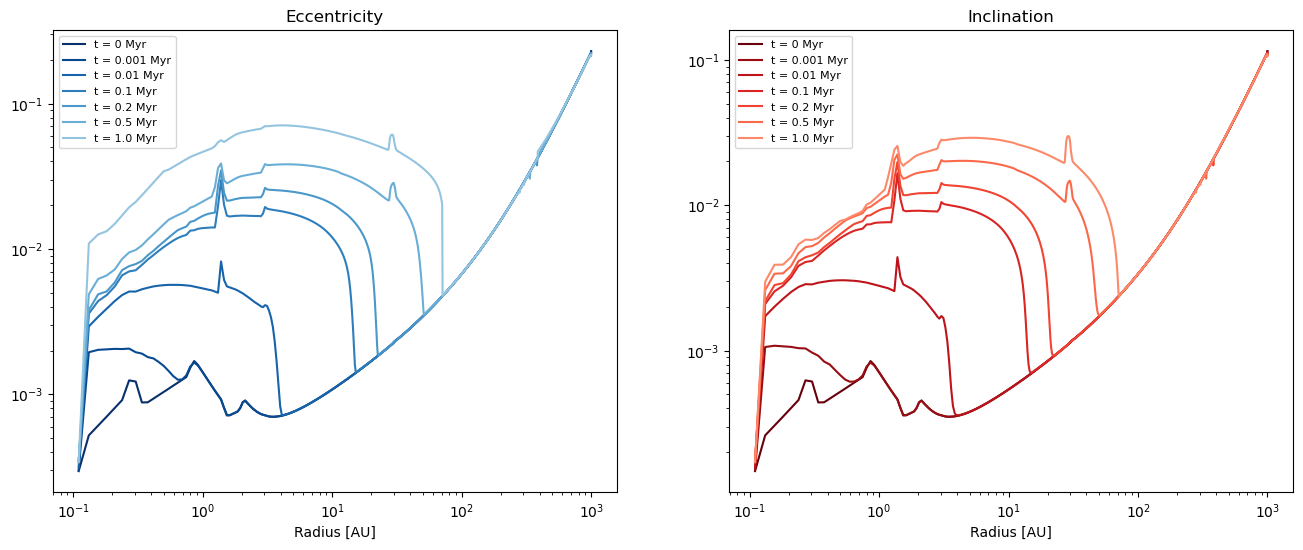

In [86]:
## Plot eccentricity and inclination profiles

n_times = len(t_interval)

fig, ax = plt.subplots(1, 2, figsize = (8 * 2, 6))

for i in range(n_times):
    ax[0].plot(R[i], e_planetesimal[i], color = color_blues[i], label = f't = {t_interval[i]} Myr')
    ax[1].plot(R[i], i_planetesimal[i], color = color_reds[i], label = f't = {t_interval[i]} Myr')

for i in range(2):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Radius [AU]')
    ax[i].legend(loc = 'upper left', fontsize = 8)

ax[0].set_title('Eccentricity')
ax[1].set_title('Inclination')

plt.show()

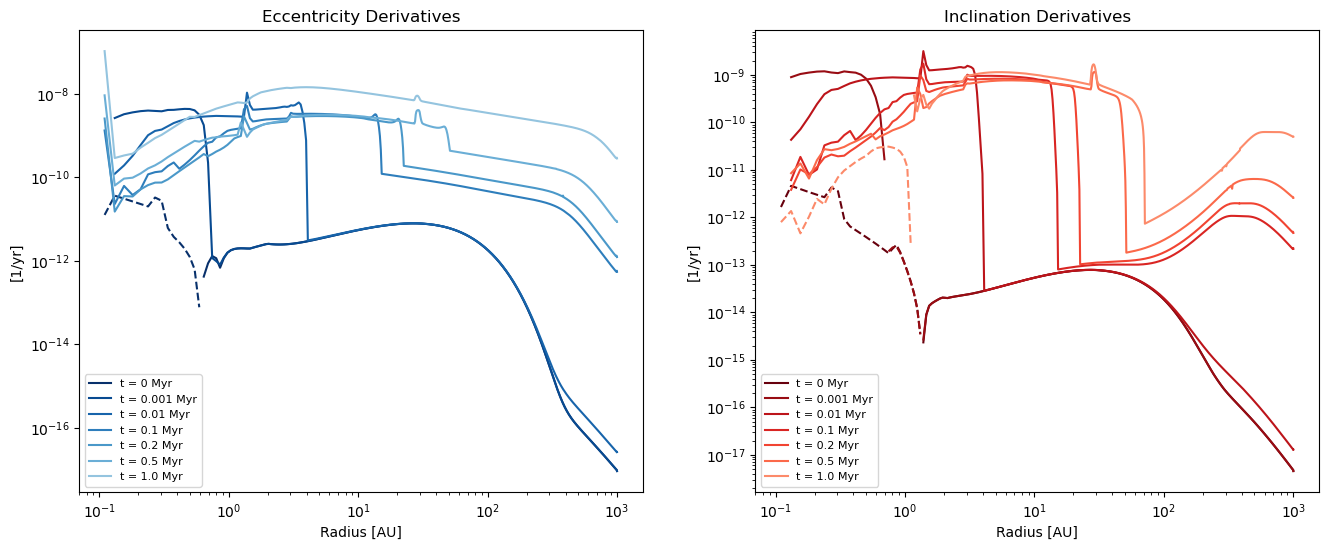

In [87]:
## Plot eccentricity and inclination derivatives

n_times = len(t_interval)

fig, ax = plt.subplots(1, 2, figsize = (8 * 2, 6))

for i in range(n_times):
    ax[0].plot(R[i], np.where(de2_dt[i] > 0, de2_dt[i], np.nan), color = color_blues[i], linestyle = '-', label = f't = {t_interval[i]} Myr')
    ax[0].plot(R[i], np.where(de2_dt[i] < 0, -1 * de2_dt[i], np.nan), color = color_blues[i], linestyle = '--')

    ax[1].plot(R[i], np.where(di2_dt[i] > 0, di2_dt[i], np.nan), color = color_reds[i], linestyle = '-', label = f't = {t_interval[i]} Myr')
    ax[1].plot(R[i], np.where(di2_dt[i] < 0, -1 * di2_dt[i], np.nan), color = color_reds[i], linestyle = '--')

for i in range(2):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Radius [AU]')
    ax[i].set_ylabel('[1/yr]')
    ax[i].legend(loc = 'lower left', fontsize = 8)

ax[0].set_title('Eccentricity Derivatives')
ax[1].set_title('Inclination Derivatives')

plt.show()

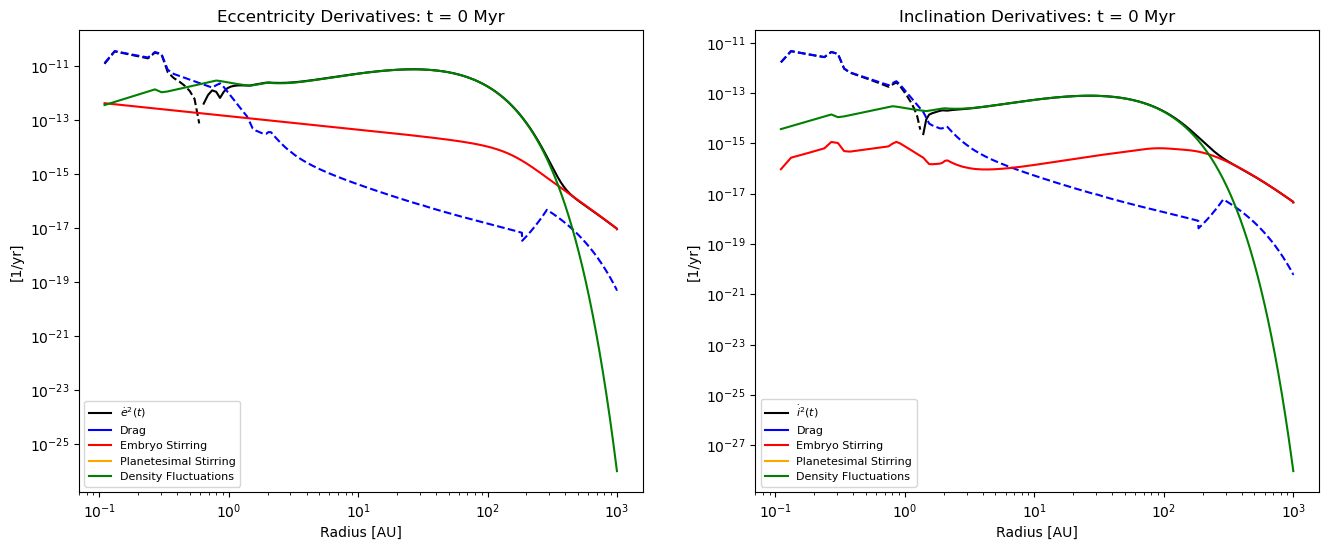

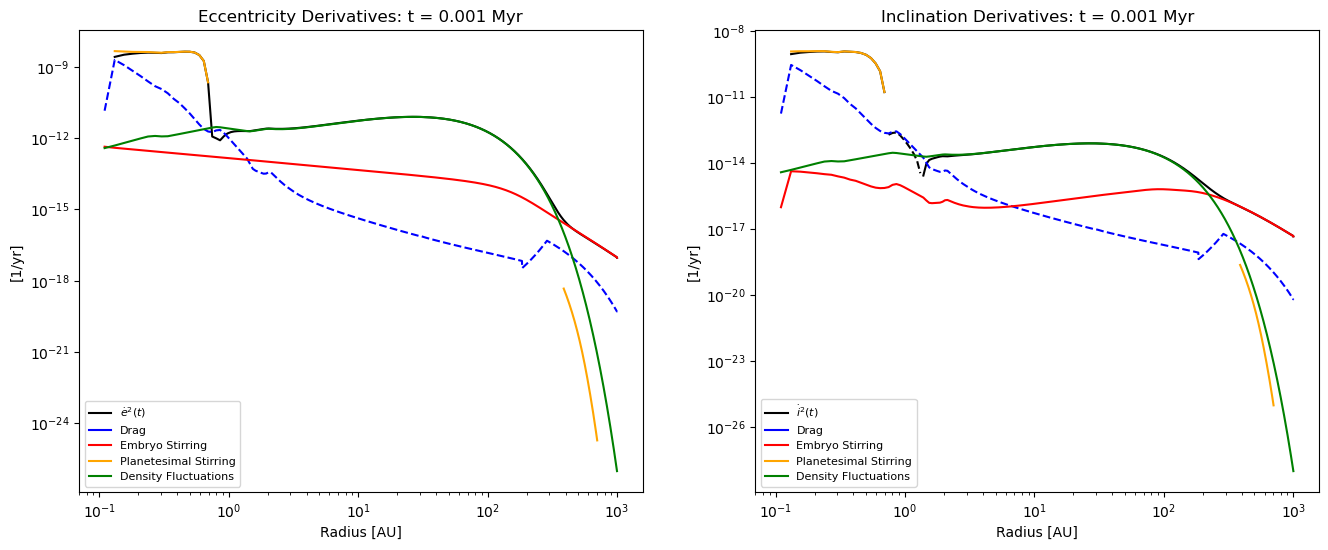

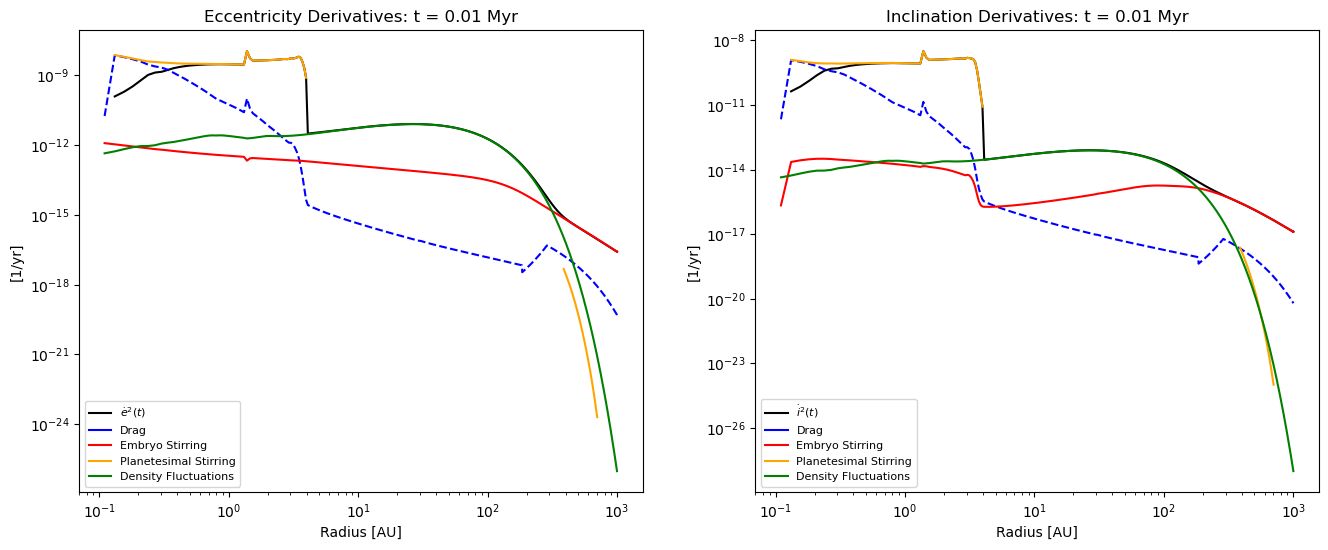

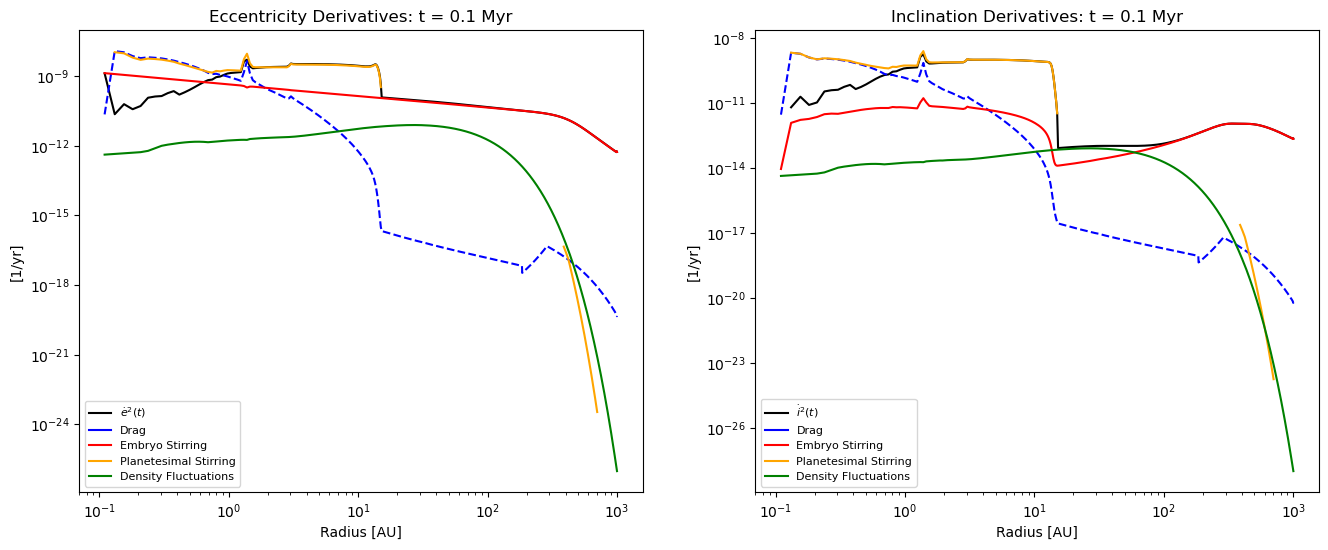

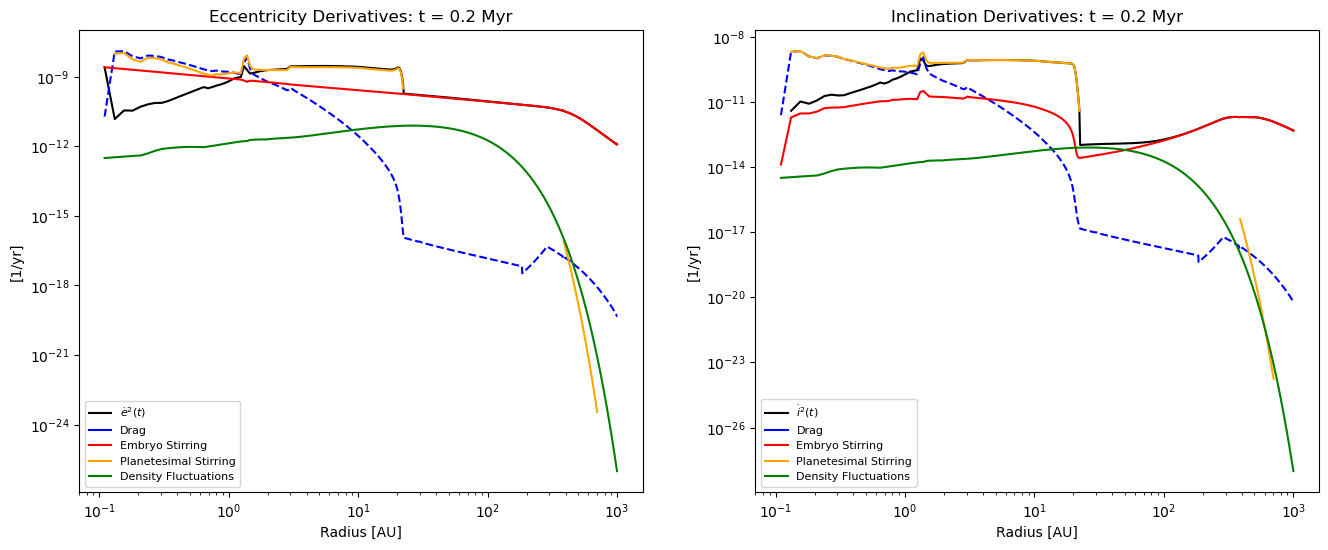

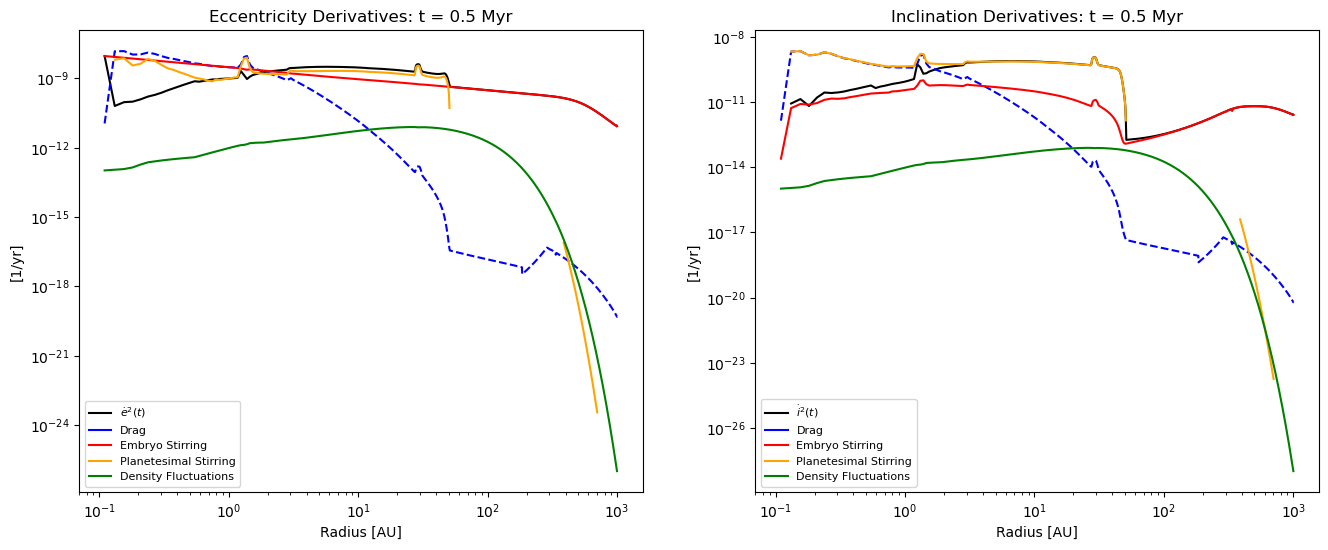

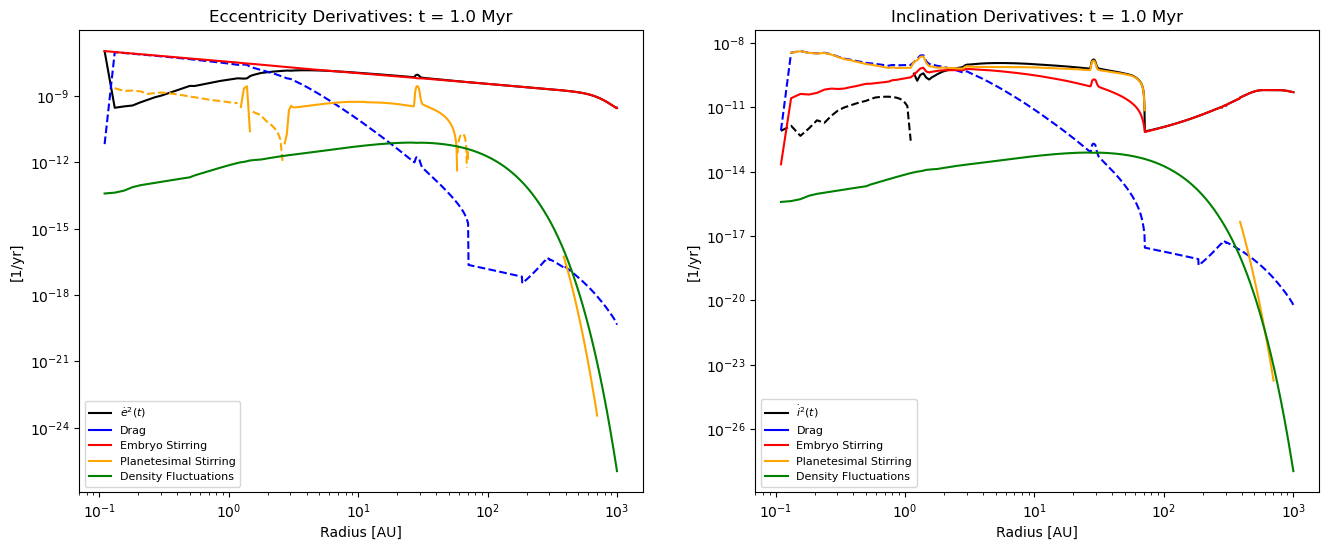

In [88]:
## Plot eccentricity and inclination derivatives

n_times = len(t_interval)

for i in range(n_times):
    fig, ax = plt.subplots(1, 2, figsize = (8 * 2, 6))

    ## Eccentricity derivatives
    ax[0].plot(R[i], np.where(de2_dt[i] > 0, de2_dt[i], np.nan), color = 'black', linestyle = '-', label = r'$\dot e^2(t)$')
    ax[0].plot(R[i], np.where(de2_dt[i] < 0, -1 * de2_dt[i], np.nan), color = 'black', linestyle = '--')
    
    ## Drag
    ax[0].plot(R[i], np.where(de2_dt_drag[i] > 0, de2_dt_drag[i], np.nan), color = 'blue', linestyle = '-', label = 'Drag')
    ax[0].plot(R[i], np.where(de2_dt_drag[i] < 0, -1 * de2_dt_drag[i], np.nan), color = 'blue', linestyle = '--')

    ## VS_embryo
    ax[0].plot(R[i], np.where(de2_dt_VS_embryo[i] > 0, de2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '-', label = 'Embryo Stirring')
    ax[0].plot(R[i], np.where(de2_dt_VS_embryo[i] < 0, -1 * de2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '--')

    ## VS_pltsml
    ax[0].plot(R[i], np.where(de2_dt_VS_pltsml[i] > 0, de2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '-', label = 'Planetesimal Stirring')
    ax[0].plot(R[i], np.where(de2_dt_VS_pltsml[i] < 0, -1 * de2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '--')

    ## DF
    ax[0].plot(R[i], np.where(de2_dt_DF[i] > 0, de2_dt_DF[i], np.nan), color = 'green', linestyle = '-', label = 'Density Fluctuations')
    ax[0].plot(R[i], np.where(de2_dt_DF[i] < 0, -1 * de2_dt_DF[i], np.nan), color = 'green', linestyle = '--')

    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].set_xlabel('Radius [AU]')
    ax[0].set_ylabel('[1/yr]')
    ax[0].set_title(f'Eccentricity Derivatives: t = { t_interval[i]} Myr')
    ax[0].legend(loc = 'lower left', fontsize = 8)

    ## Inclination derivatives
    ax[1].plot(R[i], np.where(di2_dt[i] > 0, di2_dt[i], np.nan), color = 'black', linestyle = '-', label = r'$\dot i^2(t)$')
    ax[1].plot(R[i], np.where(di2_dt[i] < 0, -1 * di2_dt[i], np.nan), color = 'black', linestyle = '--')

    ## Drag
    ax[1].plot(R[i], np.where(di2_dt_drag[i] > 0, di2_dt_drag[i], np.nan), color = 'blue', linestyle = '-', label = 'Drag')
    ax[1].plot(R[i], np.where(di2_dt_drag[i] < 0, -1 * di2_dt_drag[i], np.nan), color = 'blue', linestyle = '--')

    ## VS_embryo
    ax[1].plot(R[i], np.where(di2_dt_VS_embryo[i] > 0, di2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '-', label = 'Embryo Stirring')
    ax[1].plot(R[i], np.where(di2_dt_VS_embryo[i] < 0, -1 * di2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '--')

    ## VS_pltsml
    ax[1].plot(R[i], np.where(di2_dt_VS_pltsml[i] > 0, di2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '-', label = 'Planetesimal Stirring')
    ax[1].plot(R[i], np.where(di2_dt_VS_pltsml[i] < 0, -1 * di2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '--')

    ## DF
    ax[1].plot(R[i], np.where(di2_dt_DF[i] > 0, di2_dt_DF[i], np.nan), color = 'green', linestyle = '-', label = 'Density Fluctuations')
    ax[1].plot(R[i], np.where(di2_dt_DF[i] < 0, -1 * di2_dt_DF[i], np.nan), color = 'green', linestyle = '--')

    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].set_xlabel('Radius [AU]')
    ax[1].set_ylabel('[1/yr]')
    ax[1].set_title(f'Inclination Derivatives: t = { t_interval[i]} Myr')
    ax[1].legend(loc = 'lower left', fontsize = 8)


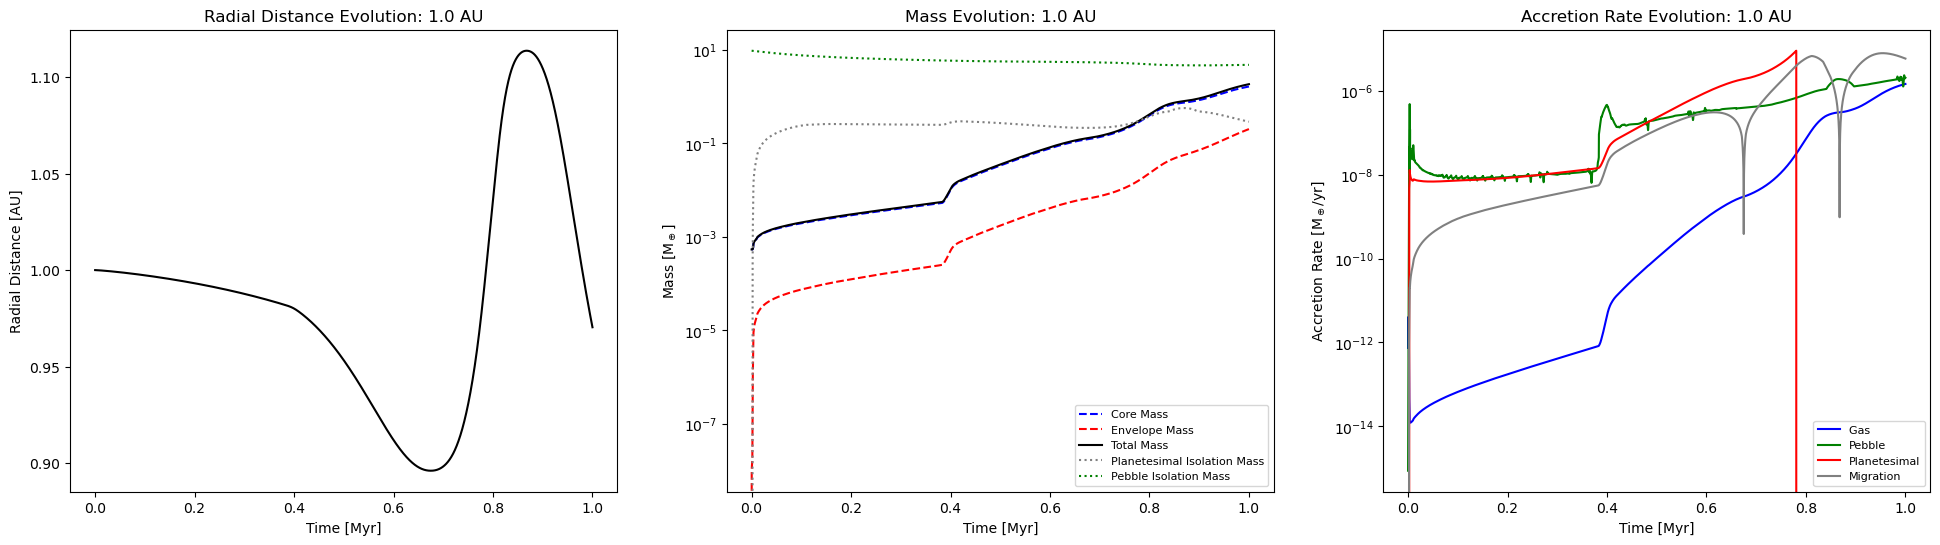

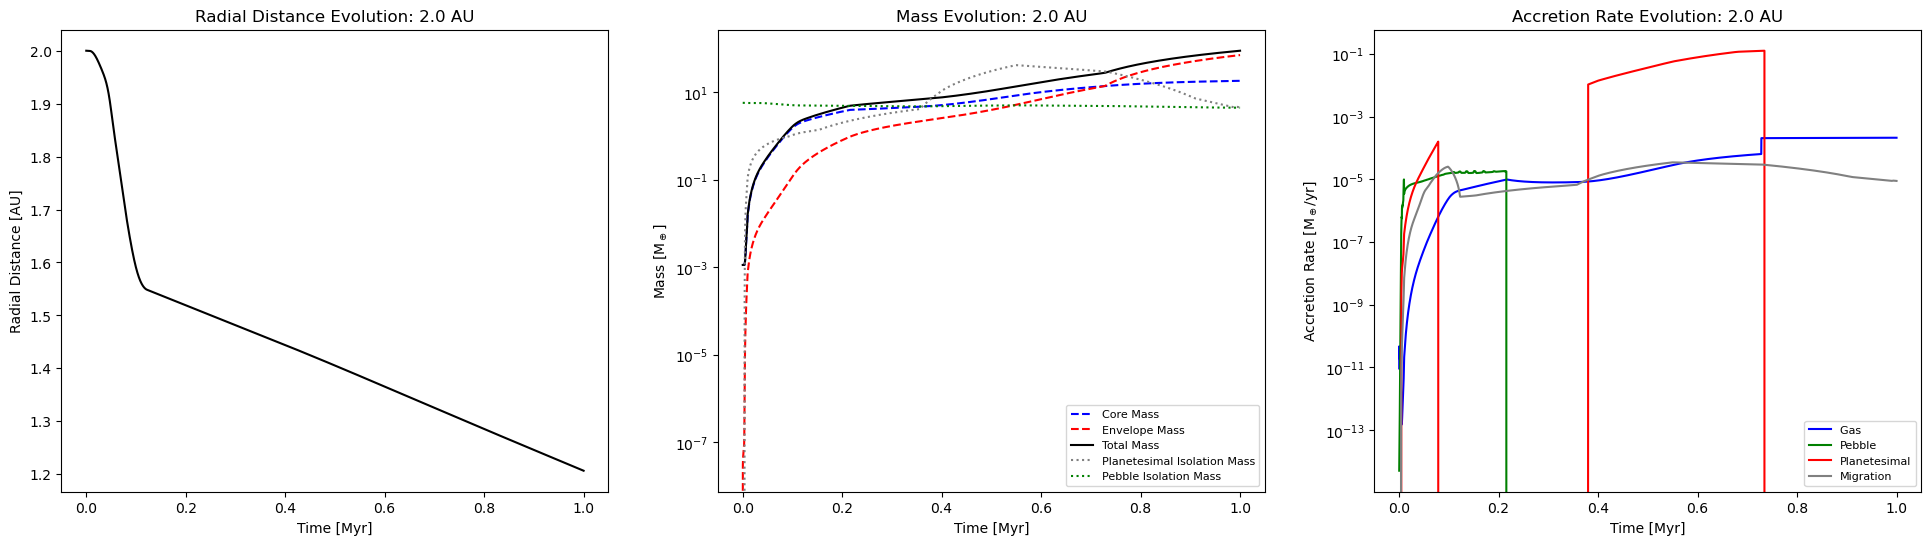

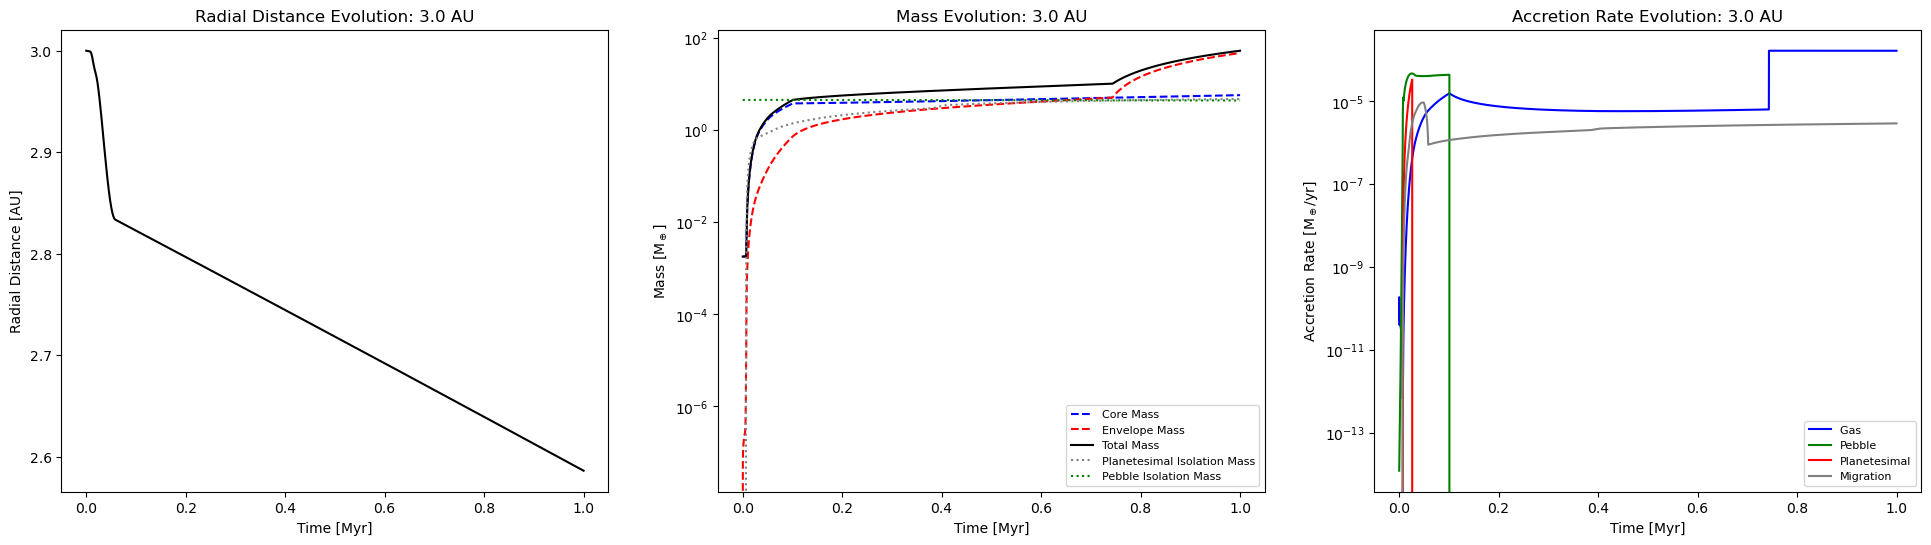

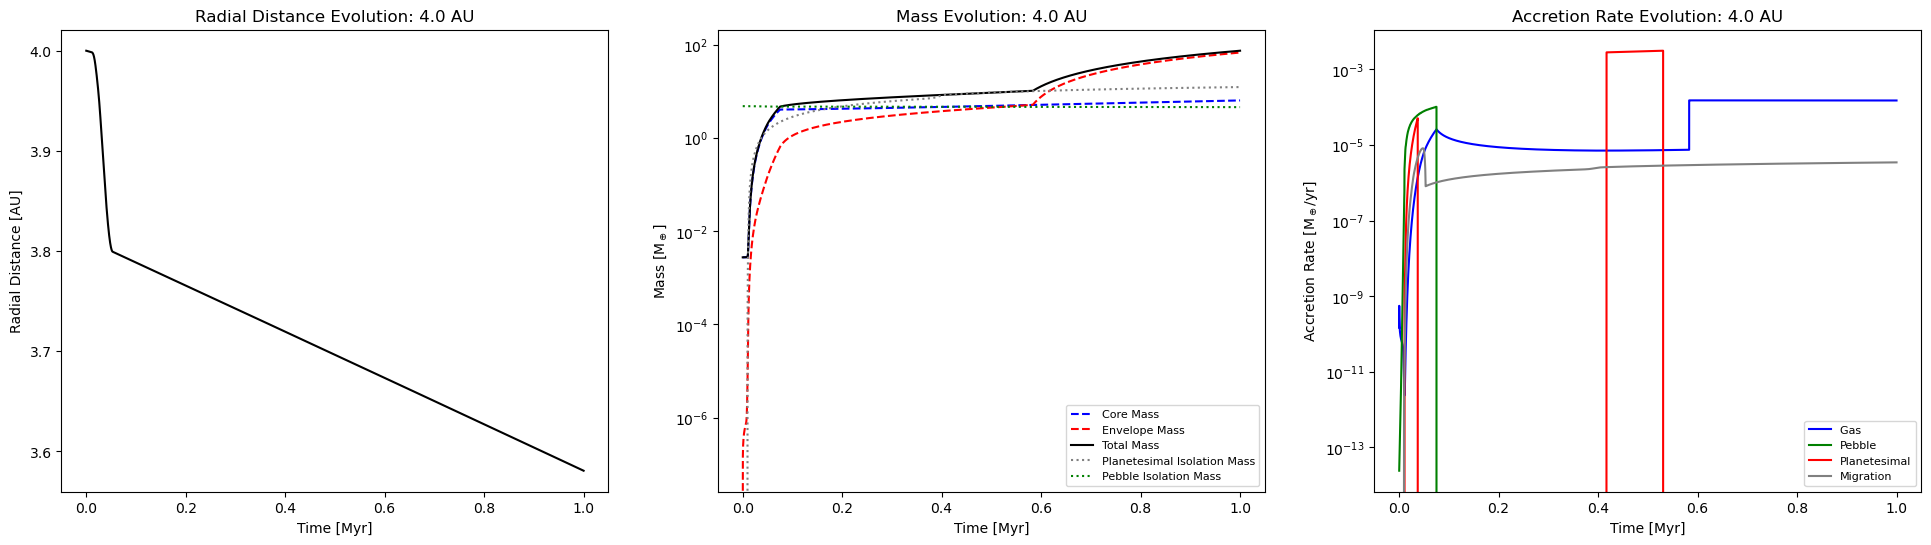

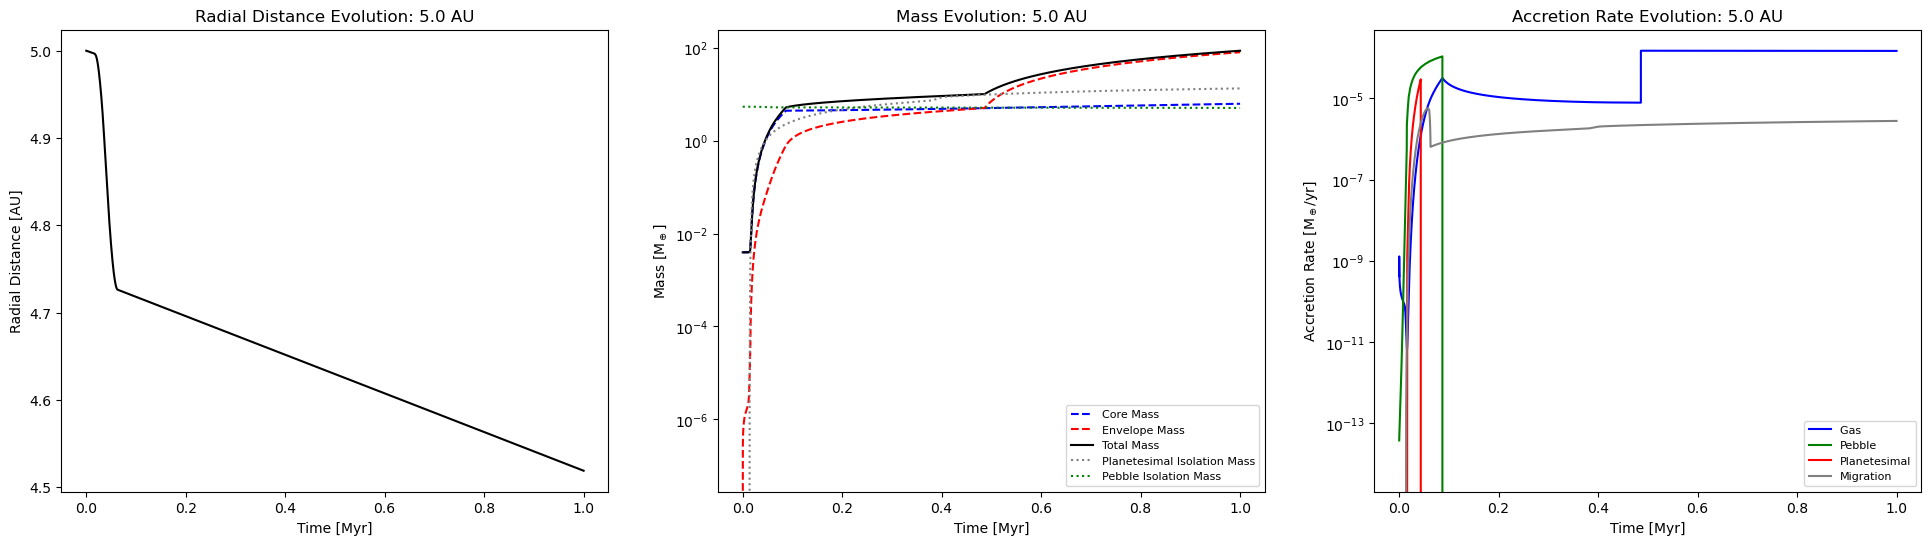

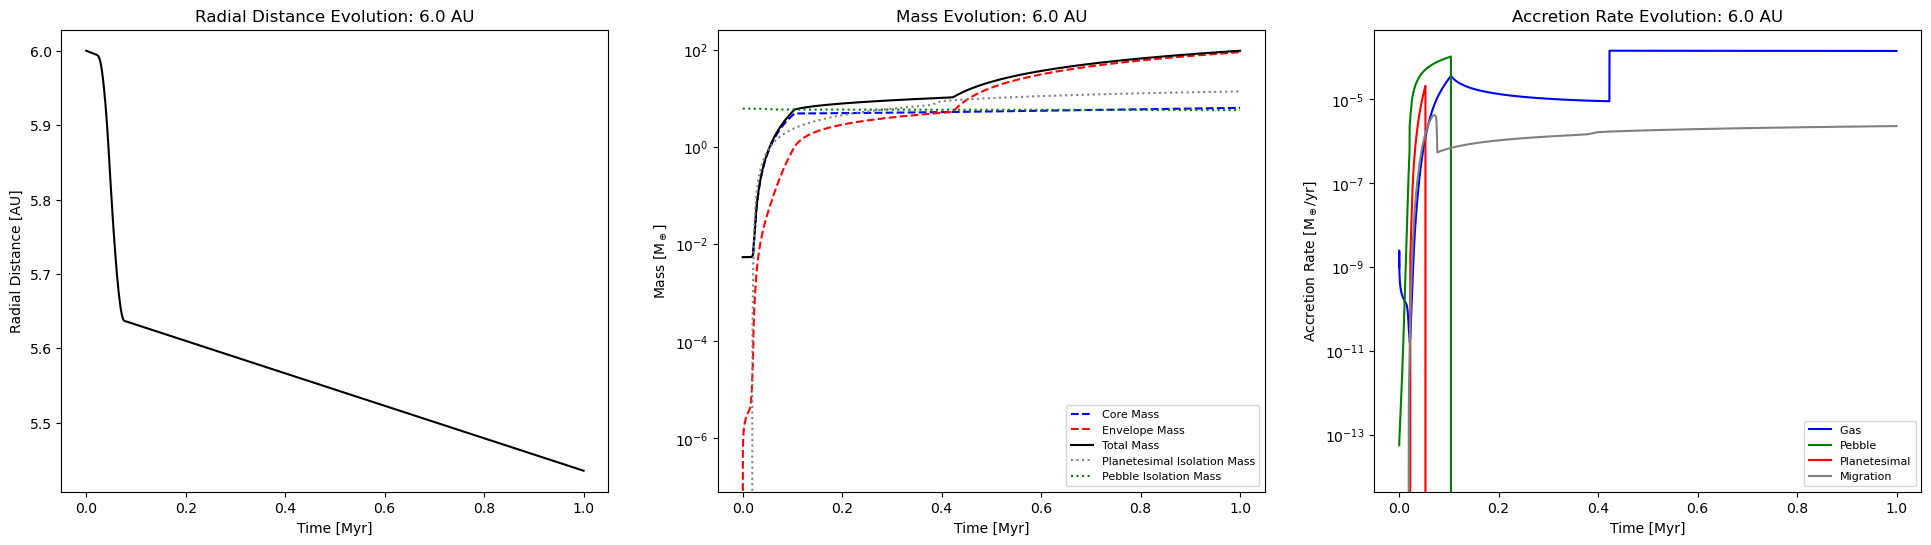

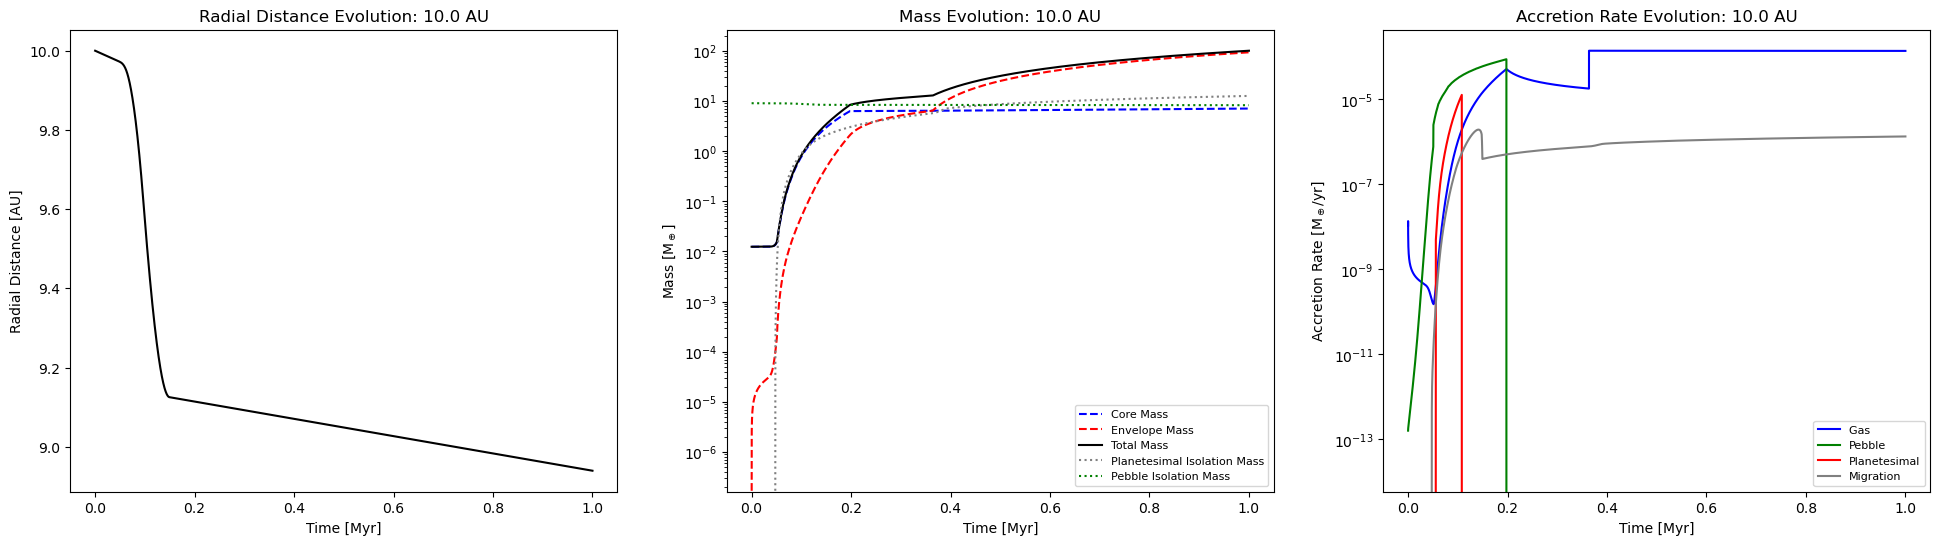

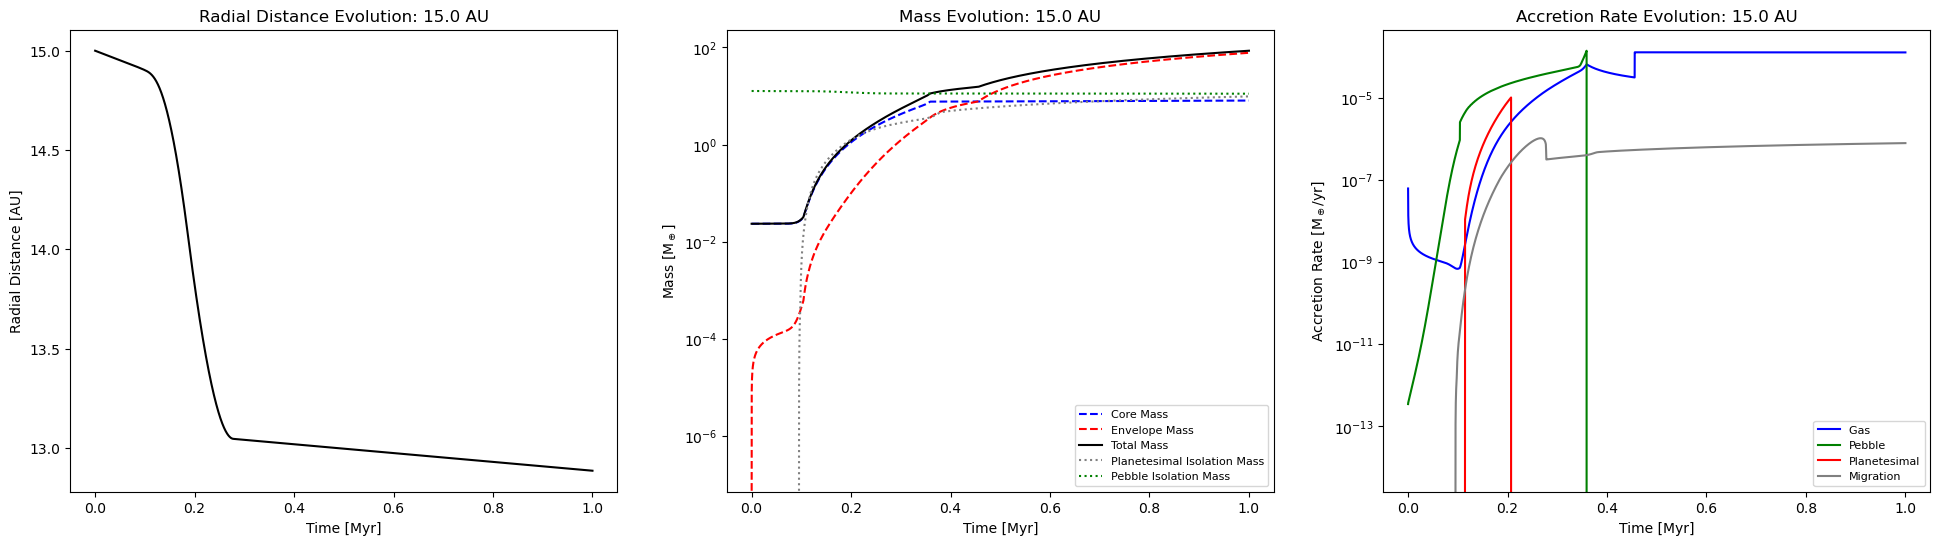

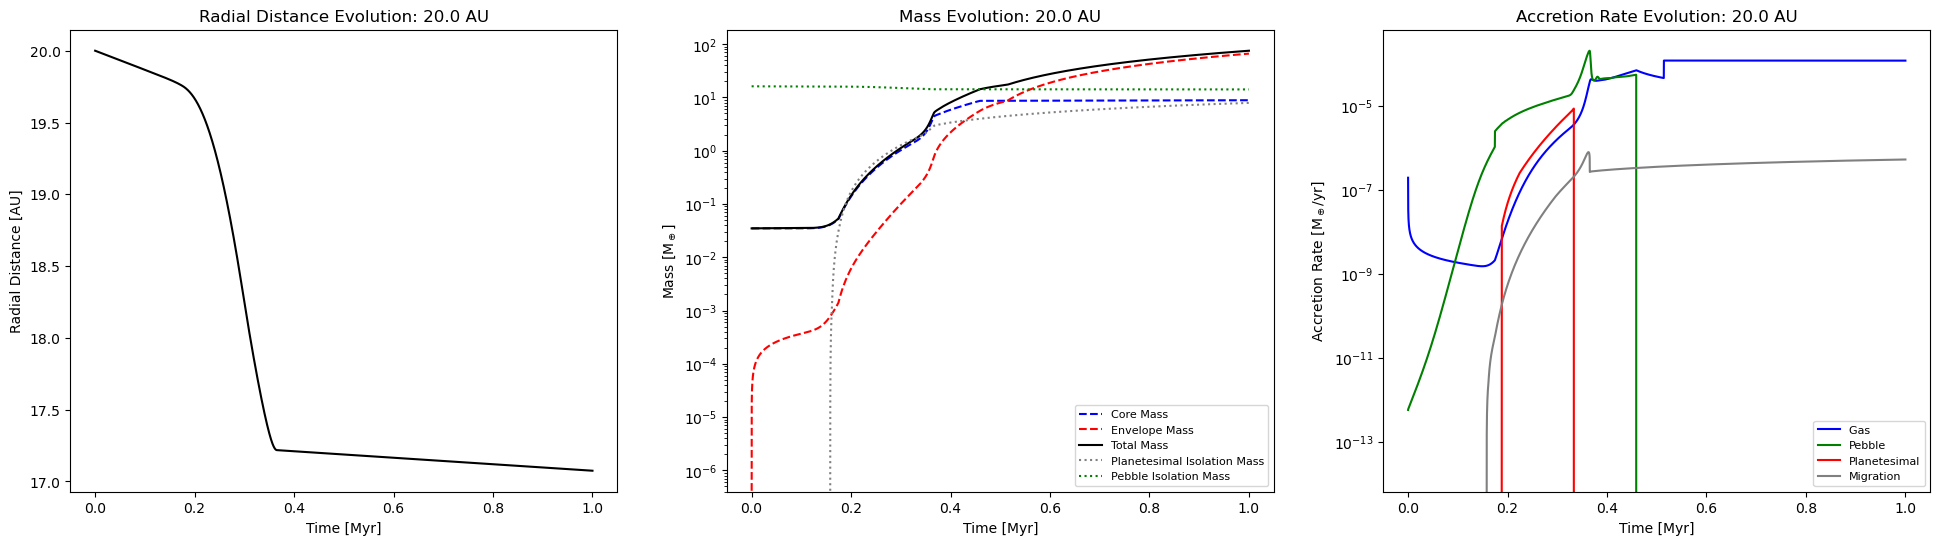

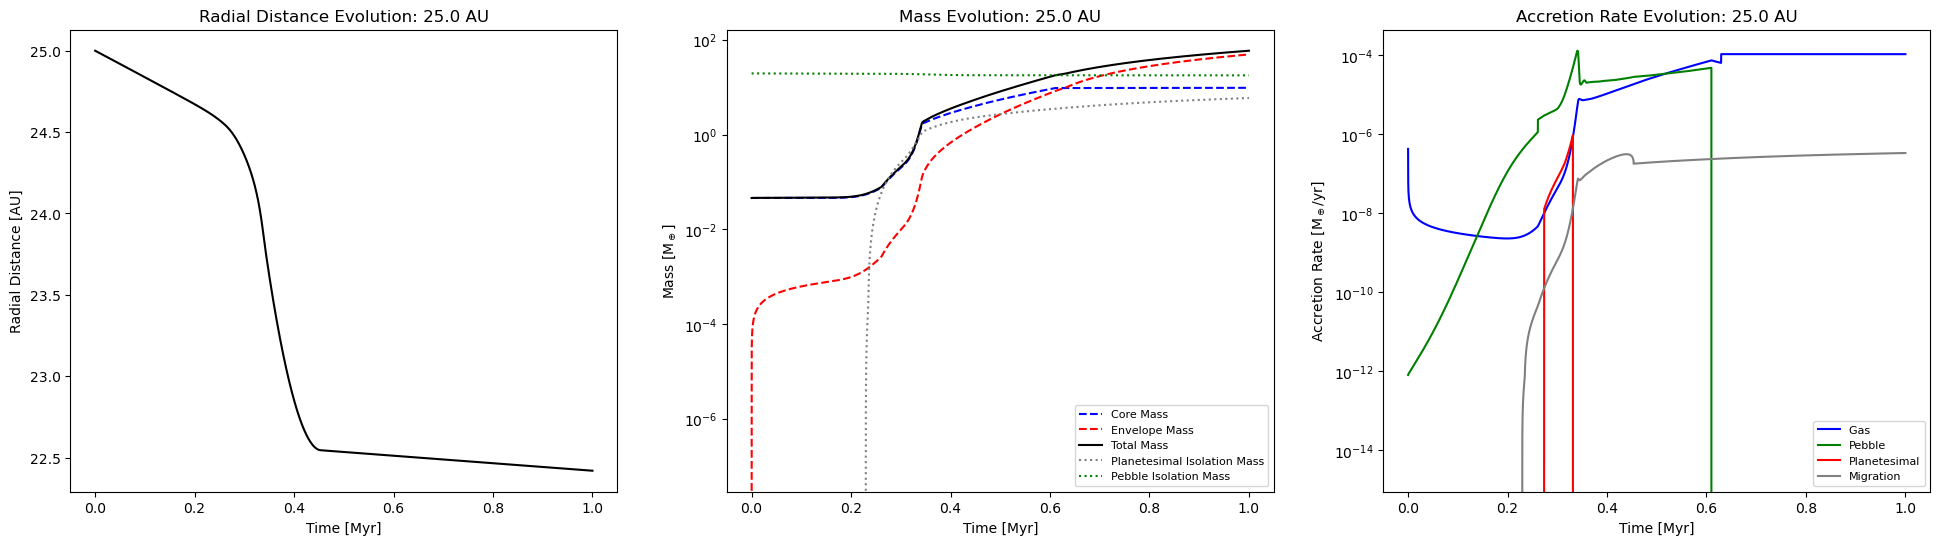

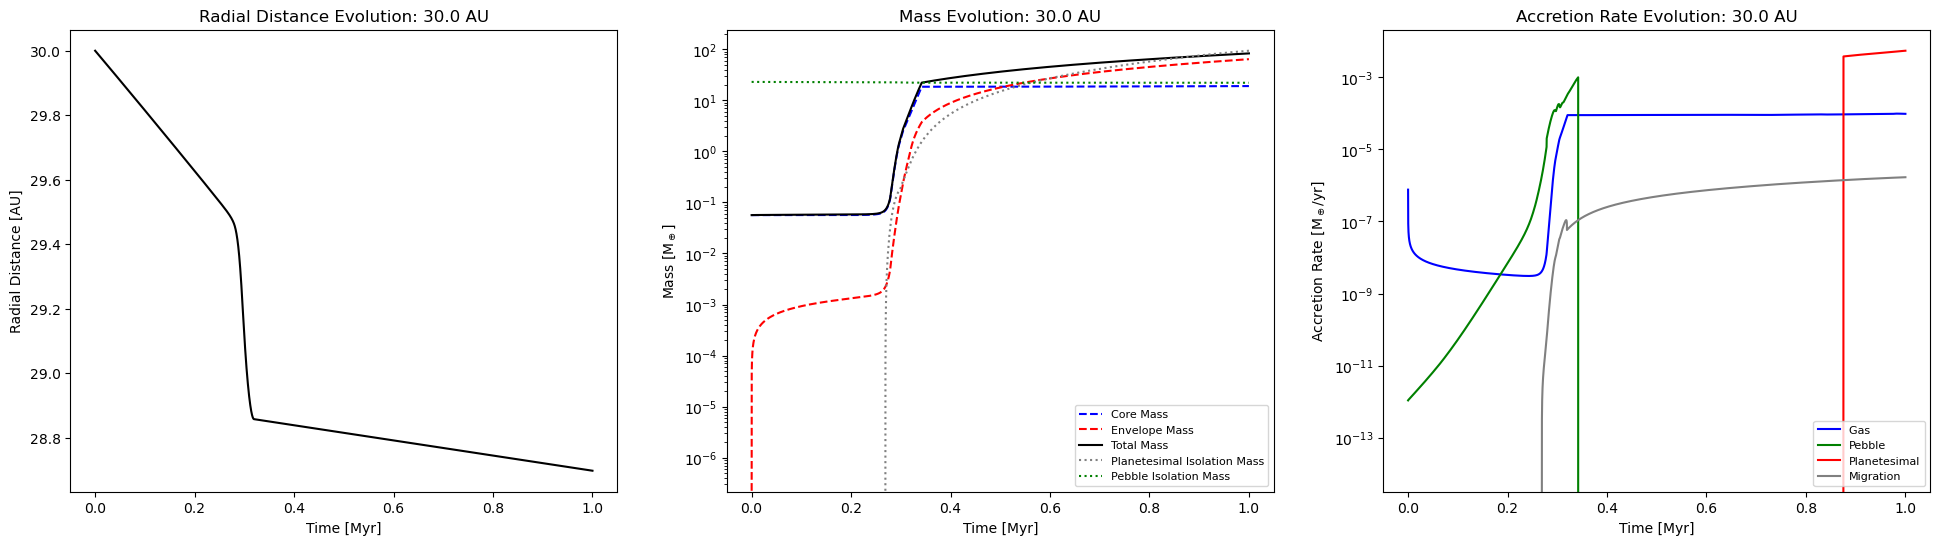

In [89]:
## Plot mass, accretion rate, and radial distance evolution of the planet

n_planets = len(Rp)

for i in range(n_planets):
    fig, ax = plt.subplots(1, 3, figsize = (8 * 3, 6))

    ## Radial distance evolution
    ax[0].plot(t / 1e6, Rp[i], color = 'black')

    ax[0].set_xlabel('Time [Myr]')
    ax[0].set_ylabel('Radial Distance [AU]')
    ax[0].set_title(f'Radial Distance Evolution: {Rp[i][0]} AU')

    ## Mass evolution
    ax[1].plot(t / 1e6, Mcs[i], color = 'blue', linestyle = '--', label = f'Core Mass')
    ax[1].plot(t / 1e6, Mes[i], color = 'red', linestyle = '--', label = f'Envelope Mass')
    ax[1].plot(t / 1e6, Mcs[i] + Mes[i], color = 'black', label = f'Total Mass')

    ax[1].plot(t / 1e6, M_iso_planetesimal[i], color = 'grey', linestyle = ':', label = f'Planetesimal Isolation Mass')
    ax[1].plot(t / 1e6, M_iso_pebble[i], color = 'green',  linestyle = ':', label = f'Pebble Isolation Mass')

    ax[1].set_yscale('log')
    ax[1].set_xlabel('Time [Myr]')
    ax[1].set_ylabel(r'Mass [M$_\oplus$]')
    ax[1].set_title(f'Mass Evolution: {Rp[i][0]} AU')
    ax[1].legend(loc = 'lower right', fontsize = 8)

    ## Accretion rate evolution
    ax[2].plot(t / 1e6, Mdot_gas[i], color = 'blue', label = f'Gas ')
    ax[2].plot(t / 1e6, Mdot_pebble[i], color = 'green', label = f'Pebble')
    ax[2].plot(t / 1e6, Mdot_planetesimal[i], color = 'red', label = f'Planetesimal')
    ax[2].plot(t / 1e6, Mdot_migration[i], color = 'grey', label = f'Migration')

    ax[2].set_yscale('log')
    ax[2].set_xlabel('Time [Myr]')
    ax[2].set_ylabel(r'Accretion Rate [M$_\oplus$/yr]')
    ax[2].set_title(f'Accretion Rate Evolution: {Rp[i][0]} AU')
    ax[2].legend(loc = 'lower right', fontsize = 8)


    plt.show()

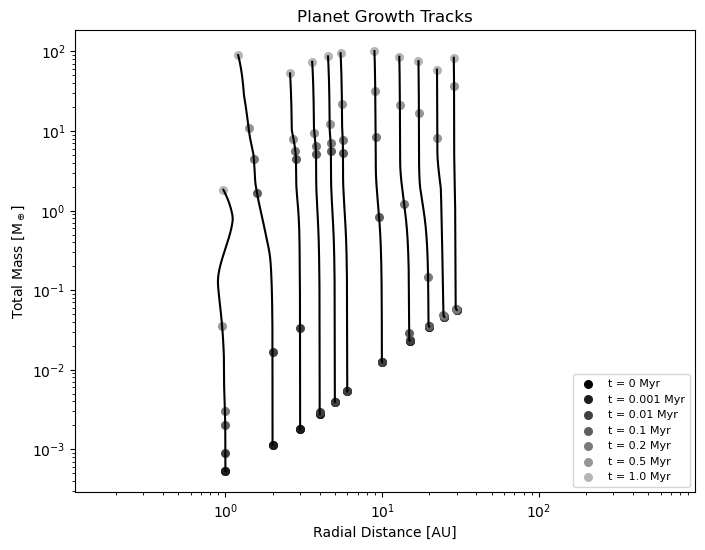

In [90]:
## Plot planet growth tracks

n_planets = len(Rp)
n_times = len(t_interval)

fig, ax = plt.subplots(figsize = (8, 6))

for i in range(n_planets):
    ax.plot(Rp[i], Mcs[i] + Mes[i], color = 'black')

    for j in range(n_times):
        k = np.array([np.argmin(np.abs(t / 1e6 - t_interval[j]))])

        if i == 0:
            label = f't = {t_interval[j]} Myr' if i == 0 else None
        else:
            label = None
            
        ax.scatter(Rp[i][k], Mcs[i][k] + Mes[i][k], color = color_greys[j], s = 30, label = label)

ax.set_xlim(R[0][0], R[0][-1])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radial Distance [AU]')
ax.set_ylabel(r'Total Mass [M$_\oplus$]')
ax.set_title('Planet Growth Tracks')
plt.legend(loc = 'lower right', fontsize = 8)

plt.show()